## Phase 4 - Data Modeling

In Phase 4 of CRISP-DM we build and evaluate the predictive model. The goal is to answer Analytical Objective 2 from Phase 1: predict whether a customer will be a detractor before the NPS survey.


In [1]:
# Libraries from Phase 3 — Data Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Choosing a classification model

We start with logistic regression and then move to random forest.  
Logistic regression is the baseline: The starting point. If random forest does not beat logistic regression, something is off.  
Random forest is the main model: more robust, handles class imbalance better, and will likely hit the metrics we set in Question 1.


### Classification model — Logistic regression

Logistic regression outputs a probability between 0 and 1, which is then mapped to a class.

Predict whether a customer will be a detractor → yes or no  
Predict whether a customer will be a detractor → 1 or 0

Our target is `nps_detrator`, with only two possible values: 0 or 1.

“Will this customer be a detractor?”  
That is what the model must predict.

Logistic regression does this with the sigmoid, which squashes any score into (0, 1), representing the probability of being a detractor or not.


In [2]:
# Model algorithm
from sklearn.linear_model import LogisticRegression
# Feature scaling
from sklearn.preprocessing import StandardScaler
# Metrics
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score

# 1. Load data
X_train = pd.read_csv('X_train.csv')  # training features
X_test = pd.read_csv('X_test.csv')  # test features
y_train = pd.read_csv('y_train.csv')  # training target
y_test = pd.read_csv('y_test.csv')  # test target


In [3]:
# 2. Standardization (important for logistic regression)
# Because order_value is in hundreds and complaints_count in single digits,
# the scaler puts every feature on a comparable scale.
scaler = StandardScaler()  # create scaler
X_train_scaled = scaler.fit_transform(X_train)  # learn scale on train and transform
X_test_scaled = scaler.transform(X_test)  # apply train scale to test

# fit_transform only on train
# transform only on test—otherwise we would leak future information into the model.


In [4]:
# 3. Train the model (fit)
# Target column is nps_detrator (1 = detractor, 0 = promoter/neutral)
# class_weight="balanced" helps with class imbalance

# class_weight="balanced" offsets 74% detractors / 26% non-detractors
# random_state=42 for reproducibility
model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

# fit → model learns patterns from training data
# values.ravel() → turn y_train DataFrame into 1-D array for sklearn
model.fit(X_train_scaled, y_train.values.ravel())


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [5]:
# 4. Class predictions and probabilities
y_pred = model.predict(X_test_scaled)  # predicted class (0 or 1) per customer

# Probability of being a detractor (class 1)
y_probs = model.predict_proba(X_test_scaled)[:, 1]  # [:, 1] → column for class 1 (detractor)


In [6]:
# 5. Print classification metrics
print("--- Classification report ---")
# Precision, recall, F1 per class
print(classification_report(y_test, y_pred))

# (1 = detractor, 0 = promoter/neutral)


--- Classification report ---
              precision    recall  f1-score   support

           0       0.61      0.79      0.69       137
           1       0.91      0.81      0.86       363

    accuracy                           0.80       500
   macro avg       0.76      0.80      0.77       500
weighted avg       0.83      0.80      0.81       500



**Recall** — "Of all actual detractors, how many did the model find?"  
Recall of 81% → The model correctly identifies 81% of real detractors. On the test set, that is 294 of 363 customers. 69 customers are classified as "promoter/neutral."

**Precision** — "Of everyone the model labeled a detractor, how many truly were?"  

Precision of 91% → When the model says a customer is a detractor, it is right 91% of the time.  

Of all 323 customers the model labeled as detractors, 91% (294) really were detractors. The other 9% (29) were false alarms.  

High precision = few false alarms (customers who would have been promoters).

| | Predicted non-detractor | Predicted detractor | **Actual total** |
|---|---|---|---|
| **Actual non-detractor** | 108 | 29 | **137** |
| **Actual detractor** | 69 | 294 | **363** |
| **Predicted total** | **177** | **323** | **500** |


**F1-score** — "Harmonic balance between precision and recall"  
F1 of 0.86 → Strong balance between precision and recall.   

| F1 | Interpretation |
|---|---|
| < 0.50 | Poor model |
| 0.50 - 0.70 | Fair model |
| 0.70 - 0.85 | Good model |
| 0.85 - 1.00 | Excellent model |


The model balances about 86% between finding real detractors (recall 81%) and being right when it flags a detractor (precision 91%).  

<br>

**Class 0 — Non-detractor**  

| Metric | Value |
|---|---|
| Precision | 0.61 |
| Recall | 0.79 |
| F1-score | 0.69 |
| Support | 137 |  

Recall — "Of all actual non-detractors (137), how many did the model find?"  

Of 137 customers who were truly not detractors, the model got 108 right (79%). The other 29 were wrongly labeled as detractors.  

Precision — "Of everyone the model said was a non-detractor (108 + 69 = 177), how many truly were?"  

Of all customers the model called "non-detractor," only 61% (108/177) really were. The other 39% were detractors the model misclassified.  

**Is that dangerous for the business?** 

Those 69 people are detractors the model missed it treated them as satisfied when they are not. The company will not act preventively for them.  

That ties directly to class-1 recall: the more detractors slip through, the lower recall. That is why recall is the priority metric in this project.   

<br>

**Class 1 — Detractor**

| Metric | Value |
|---|---|
| Precision | 0.91 |
| Recall | 0.81 |
| F1-score | 0.86 |
| Support | 363 |  

Recall — "Of all actual detractors (363), how many did the model find?"  


Of 363 customers who truly were detractors, the model got 294 right (81%). The other 69 were labeled "non-detractor." 

Precision — "Of everyone the model said was a detractor (29 + 294 = 323), how many truly were?"  

The model predicted 323 detractors; of those, 294 (91%) really were detractors and 29 (9%) were false alarms.  


**Is that dangerous for the business?**   

The 69 detractors mislabeled as "non-detractor" are the most expensive error. The company will not intervene early; they will still answer the NPS survey with a score ≤ 6, and dissatisfaction is discovered only later, when it is harder to act.  

**Comparing the two errors:**  

29 false alarms (class 0) → the company reaches out preventively to a satisfied customer → low cost  
69 missed detractors (class 1) → the company loses the chance to act → high cost  

That is why recall is the priority metric: reducing the 69 matters more than reducing the 29.  


<br>

#### Confusion matrix  

| | Predicted non-detractor | Predicted detractor |
|---|---|---|
| **Actual non-detractor** | 108 | 29 |
| **Actual detractor** | 69 | 294 |  

<br>

Of 137 actual non-detractors → the model got 108 right and 29 wrong  
Of 363 actual detractors → the model got 294 right and 69 wrong  
  
- The 29 sits in "actual non-detractor + predicted detractor"—customers who were not detractors but the model said they were.  
- The 69 sits in "actual detractor + predicted non-detractor"—customers who were detractors but the model said they were not.    

Those counts line up with recall for class 0 and class 1, respectively.
<br> 





In [7]:
# 6. Compute and print AUC-ROC
# Area under the ROC curve — closer to 1 is better
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC-ROC score: {auc_score:.4f}")


AUC-ROC score: 0.8739


**AUC-ROC**  
Overall ability of the model to separate detractors from non-detractors.

Ranges from 0 to 1: closer to 1 is better.  
0.5 = random model (gray line on the chart)  
1.0 = perfect model


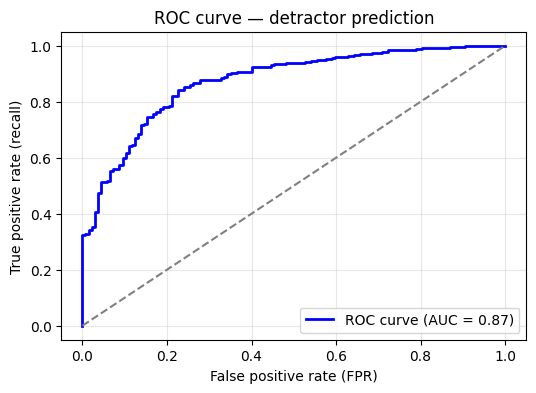

In [8]:
# 7. Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
# fpr = false positive rate (x-axis)
# tpr = true positive rate / recall (y-axis)
# thresholds = decision thresholds

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')  # model curve
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # baseline
# If the curve sits above the line, the model beats chance

plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (recall)')
plt.title('ROC curve — detractor prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


**How to read the AUC-ROC chart**

The dashed gray line is a random model—like flipping a coin.  
AUC = 0.50. If your model sat on that line, it would be useless.

The blue curve is your model.  
The farther it bends toward the upper-left from the gray line, the better.

| AUC | Interpretation |
|---|---|
| 0.50 | Random model |
| 0.60 - 0.80 | Fair model |
| 0.80 - 0.90 | Good model |
| 0.90 - 1.00 | Excellent model |


**Metrics checkpoint**

Checking whether all metrics from Phase 1 — Business Understanding were met.

| Metric | Target | Result | Status |
|---|---|---|---|
| Recall | ≥ 75% | 81% | ✅ |
| AUC-ROC | ≥ 0.80 | 0.87 | ✅ |
| F1-score | ≥ 0.70 | 0.86 | ✅ |
| Precision | ≥ 60% | 91% | ✅ |


To show how the model would behave in production, we score the first customer in the test set. The model returns both the predicted class (detractor or non-detractor) and the associated probability.


In [9]:
# 8. Single-customer scoring example
# First test row, shaped for sklearn
first_customer = X_test_scaled[0].reshape(1, -1)
prediction = model.predict(first_customer)  # predicted class
probability = model.predict_proba(first_customer)  # class probabilities

print(f"\nPrediction for the first customer: {'Detractor' if prediction[0] == 1 else 'Non-detractor'}")
print(f"Probability: {probability[0][1]:.2%} of being a detractor.")



Prediction for the first customer: Detractor
Probability: 56.31% of being a detractor.


The model labeled this customer a detractor with 56.31% probability. In production, the business could set a threshold—for example, trigger preventive outreach for any customer above 50% probability.

- Lower threshold (e.g., 40%) → catches more detractors → higher recall → more false positives  
- Higher threshold (e.g., 60%) → more conservative → higher precision → more missed detractors

For the business goal of maximizing captured detractors, a threshold below 50% would usually raise recall at the cost of more false positives. Validate that choice with the business team given operational capacity for proactive outreach.

| Threshold | Recall | Precision | Effect |
|---|---|---|---|
| 30% | High | Low | Catches more detractors but pings many satisfied customers |
| 50% | Medium | Medium | sklearn default: balanced |
| 70% | Low | High | Few false alarms but many missed detractors |


### **Cross-Validation**

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import pandas as pd

X_clf = pd.read_csv('X_train.csv')
y_clf = pd.read_csv('y_train.csv').squeeze()

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

scores = cross_val_score(pipeline_lr, X_clf, y_clf, cv=5, scoring='recall')
print(f"Mean recall (5-fold CV): {scores.mean():.2f} ± {scores.std():.2f}")


Mean recall (5-fold CV): 0.80 ± 0.03


Across five different validation folds the model kept a mean recall of about 79% with only ±2% variation, showing consistency and little sign of overfitting.

| Cross-validation | Result |
|---|---|
| Mean recall (5-fold CV) | 0.79 |
| Standard deviation | ± 0.02 |
| Interpretation | Stable model — low fold-to-fold variation |


### Classification model — Random forest

Random forest learns patterns from the training data and applies them to predict the class on new rows.

**Trains on:** 2,000 orders with known `nps_detrator`  
**Predicts:** whether a new order ends as detractor (1) or non-detractor (0)

```
complaints_count > 3?
├── YES → delivery_delay_days > 2?
│         ├── YES → DETRACTOR
│         └── NO → DETRACTOR
└── NO → resolution_time_days > 5?
          ├── YES → DETRACTOR
          └── NO → NON-DETRACTOR
```

The model learns which questions to ask—and in what order—best separate detractors from non-detractors.


In [11]:
# Model algorithm
from sklearn.ensemble import RandomForestClassifier
# Metrics
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score

# 1. Load data
X_train = pd.read_csv('X_train.csv')  # training features
X_test = pd.read_csv('X_test.csv')  # test features
y_train = pd.read_csv('y_train.csv')  # training target
y_test = pd.read_csv('y_test.csv')  # test target


In [12]:
# 2. Train the model (fit)
# Target column is nps_detrator (1 = detractor, 0 = promoter/neutral)
# class_weight="balanced" helps with class imbalance

# class_weight="balanced" offsets 74% detractors / 26% non-detractors
# random_state=42 for reproducibility
model = RandomForestClassifier(class_weight="balanced", random_state=42)

# fit → model learns patterns from training data
# values.ravel() → 1-D array for sklearn
model.fit(X_train, y_train.values.ravel())


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
# 3. Class predictions and probabilities
y_pred = model.predict(X_test)  # predicted class (0 or 1) per customer

# Probability of being a detractor (class 1)
y_probs = model.predict_proba(X_test)[:, 1]  # [:, 1] → class 1 (detractor)


In [14]:
# 3. Class predictions and probabilities
y_pred = model.predict(X_test)  # predicted class (0 or 1) per customer

# Probability of being a detractor (class 1)
y_probs = model.predict_proba(X_test)[:, 1]  # [:, 1] → class 1 (detractor)


In [15]:
# 4. Print classification metrics

print("--- Classification report ---")

# Precision, recall, F1 per class

print(classification_report(y_test, y_pred))


--- Classification report ---
              precision    recall  f1-score   support

           0       0.77      0.47      0.58       137
           1       0.82      0.95      0.88       363

    accuracy                           0.82       500
   macro avg       0.80      0.71      0.73       500
weighted avg       0.81      0.82      0.80       500



**Class 0 — Non-detractor**

Recall drops to 47%: the model makes more mistakes on non-detractors in exchange for catching more detractors.

Of 137 customers who truly were not detractors, only 64 were correct (47%). The other 73 were wrongly labeled detractors—false alarms (customers who would have been promoters/neutral).

**Why does that happen?**  
When we push recall for detractors to 95%, random forest becomes more aggressive and labels more customers as detractors to avoid misses. The cost is more errors on non-detractors.

Compared with logistic regression, which got 108 (79%) of non-detractors right, random forest is clearly weaker on this class. Because our primary metric from Phase 1 is recall, that trade-off is acceptable: we prefer proactively contacting 73 satisfied customers unnecessarily to letting 18 detractors slip through without action.

Those 18 missed detractors can be reduced by lowering the threshold below 50%. Validate that with the business given operational capacity.


In [16]:
# 5. Compute and print AUC-ROC

# Area under the ROC curve — closer to 1 is better

auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC score: {auc_score:.4f}")


AUC-ROC score: 0.8488


Random forest reached AUC-ROC of 0.85—a “good” model. Although slightly below logistic regression (0.87), random forest pays back with much higher recall (95% vs 81%), which matches the business priority.


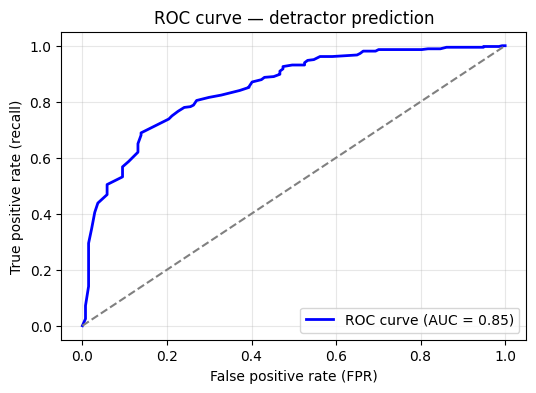

In [17]:
# 6. Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
# fpr = false positive rate (x-axis)
# tpr = true positive rate / recall (y-axis)
# thresholds = decision thresholds

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')  # model curve
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # baseline
# Above the diagonal beats chance

plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (recall)')
plt.title('ROC curve — detractor prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


**Metrics checkpoint**

Checking whether all metrics from Phase 1 — Business Understanding were met.


| Metric | Target | Result | Status |
|---|---|---|---|
| Recall | ≥ 75% | 95% | ✅ |
| AUC-ROC | ≥ 0.80 | 0.85 | ✅ |
| F1-score | ≥ 0.70 | 0.88 | ✅ |
| Precision | ≥ 60% | 82% | ✅ |


To show production behavior, we score the first customer in the test set. In practice, once a customer finishes the purchase journey, the model ingests operational fields and immediately returns the predicted class and probability so CRM can act before the NPS survey.


In [19]:
# 8. Single-customer scoring example
# First test row, shaped for sklearn
first_customer = X_test.iloc[[0]]
prediction = model.predict(first_customer)  # predicted class
probability = model.predict_proba(first_customer)  # probabilities

print(f"\nPrediction for the first customer: {'Detractor' if prediction[0] == 1 else 'Non-detractor'}")
print(f"Probability: {probability[0][1]:.2%} of being a detractor.")



Prediction for the first customer: Detractor
Probability: 89.00% of being a detractor.


The model labeled this customer a detractor with 89% probability—high confidence. In production, that customer would likely get immediate proactive outreach (call, coupon, etc.).  
Probability is more actionable than class alone: 89% deserves urgent attention; 51% might get a lighter touch.


### **Cross-validation**

To ensure the model is not only good on one particular split, we use 5-fold cross-validation: the model is trained and evaluated five times on different slices of the data.


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Recreate the model for cross-validation
model_rf_cv = RandomForestClassifier(class_weight='balanced', random_state=42)

X_clf = pd.read_csv('X_train.csv')
y_clf = pd.read_csv('y_train.csv').squeeze()

scores = cross_val_score(model_rf_cv, X_clf, y_clf, cv=5, scoring='recall')
print(f"Mean recall (5-fold CV): {scores.mean():.2f} ± {scores.std():.2f}")


Mean recall (5-fold CV): 0.94 ± 0.01


Five-fold cross-validation supports robustness. Across five evaluations random forest kept a mean recall of about 94% with only ±1% spread—almost flat across folds.  
That confirms the 95% recall on the test set was not luck; the model consistently finds detractors.

| Cross-validation | Result |
|---|---|
| Mean recall (5-fold CV) | 0.94 |
| Standard deviation | ± 0.01 |
| Interpretation | Very stable — extremely low fold-to-fold variation |


### **Feature importance**

Random forest automatically scores how much each variable contributes to predictions. That ties directly to Analytical Objective 1 from Phase 1 (Business Understanding).

“Identify which operational variables are most associated with NPS ≤ 6.”

EDA showed correlations; feature importance shows what the model actually uses to separate detractors from non-detractors.


In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)


                      feature  importance
12           complaints_count    0.231524
7         delivery_delay_days    0.157402
1      customer_tenure_months    0.070811
8               freight_value    0.069788
4              discount_value    0.069230
2                 order_value    0.066961
11       resolution_time_days    0.060615
0                customer_age    0.060458
10  customer_service_contacts    0.047843
6          delivery_time_days    0.042988
5        payment_installments    0.040481
3              items_quantity    0.031876
9           delivery_attempts    0.018172
16        customer_region_Sul    0.009125
13   customer_region_Nordeste    0.007843
15    customer_region_Sudeste    0.007542
14      customer_region_Norte    0.007340


Contribution of each variable to predictions, sorted from highest to lowest.  
The two standouts are `complaints_count` (23.1%) and `delivery_delay_days` (15.7%). Together they are nearly 40% of the model’s predictive weight.

That matches Phase 2 EDA: the same variables that correlated most with `nps_detrator` on the heatmap are what the model leans on most for dissatisfaction.

The one-hot region columns (`customer_region_*`) sit at the bottom with under 1% each, matching the regional analysis that there is no meaningful regional bias.


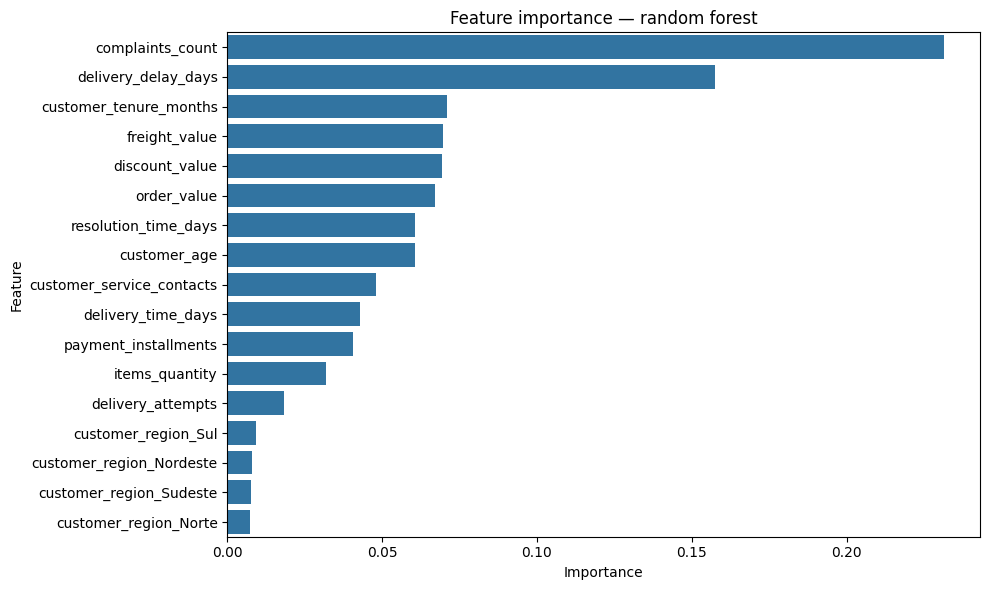

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature importance — random forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### **Key takeaways**

**1. EDA confirmation**  
The two most important model inputs are exactly the two strongest correlations from EDA—`complaints_count` (0.45) and `delivery_delay_days` (0.40). The model learned what the charts already suggested.

**2. Model surprises**  
`freight_value` and `order_value` show moderate importance (~7%) even though boxplots looked flat. Random forest can pick up non-linear patterns that simple plots miss.

**3. Region stays irrelevant**  
The four region dummies sit at the bottom, echoing the regional conclusion for Question 3.


### **Why random forest beats logistic regression here**

| | Logistic regression | Random forest |
|---|---|---|
| Variable relationships | Mostly linear | Linear and non-linear |
| Class imbalance | Needs `class_weight` | Handles imbalance more naturally |
| Interpretability | High | Medium |
| Overall performance | Strong baseline | Often stronger |

**Main hyperparameters**

`n_estimators` → number of trees. More trees = more robust but slower. Default: 100.

`class_weight='balanced'` → same idea as in logistic regression—offsets imbalance.

`random_state=42` → reproducibility.


### **Logistic regression vs random forest**

| Metric | Target | Logistic regression | Random forest | Winner |
|---|---|---|---|---|
| Recall | ≥ 75% | 81% | 95% | 🏆 Random forest |
| AUC-ROC | ≥ 0.80 | 87% | 85% | 🏆 Logistic regression |
| F1-score | ≥ 0.70 | 86% | 88% | 🏆 Random forest |
| Precision | ≥ 60% | 91% | 82% | 🏆 Logistic regression |

**What does that mean?**  
Random forest wins on recall: it catches 95% of real detractors vs 81% for logistic regression.  
For the business goal, that is what matters most.

Logistic regression wins on precision: 91% vs 82%. Random forest creates more false positives. For this use case, false positives are usually cheaper than missed detractors who then score low on NPS.

Class 0 (non-detractor) got worse with random forest

Recall fell from 79% to 47%—more mistakes on non-detractors.  
That is expected: as recall for detractors rises, the model labels more rows as detractors.


### **Selected classification model: random forest**

The production pick is random forest. Phase 1 made recall the priority: catch as many detractors as possible before they rate the company poorly. Random forest reaches 95% recall vs 81% for logistic regression—about 14 more true detractors caught per 100 actual detractors.

Even though precision fell from 91% to 82%, proactively contacting a happy customer is cheaper than missing a detractor, as documented in Phase 1.

Both models met the technical targets, but random forest aligns better with the business objective of maximizing capture of dissatisfied customers.


## **Regression model — Linear regression**

In the regression track we predict the NPS score, a numeric target from 0 to 10.  
A natural first algorithm is linear regression: it fits the best linear relationship between features and `nps_score`.

We use it as a simple baseline, then compare against random forest regressor.

| Metric | What it measures |
|---|---|
| **MAE** | Mean absolute error in NPS points |
| **RMSE** | Root mean squared error — punishes large errors |
| **R²** | Share of NPS variance explained by the model |


In [ ]:
# Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load CSV
# (Regression uses nps_score as target; keep it in the frame for now)

df = pd.read_csv("desafio_nps_fase_1.csv")

df.head()


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### Dropping variables

Remove low-value columns and those blocked because of leakage (`csat_internal_score`, `repeat_purchase_30d`).




In [ ]:
columns_to_drop = ['customer_id', 'order_id', 'csat_internal_score', 'repeat_purchase_30d']

df = df.drop(columns_to_drop, axis=1)
df.head()


,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


### Handling categorical variables

Machine learning models do not read raw text like "Sudeste" or "Sul". We encode that column with **one-hot encoding**.


In [ ]:
df = pd.get_dummies(df, columns=['customer_region'], drop_first=True)

df.columns


Index(['customer_age', 'customer_tenure_months', 'order_value',
       'items_quantity', 'discount_value', 'payment_installments',
       'delivery_time_days', 'delivery_delay_days', 'freight_value',
       'delivery_attempts', 'customer_service_contacts',
       'resolution_time_days', 'nps_score', 'complaints_count',
       'customer_region_Nordeste', 'customer_region_Norte',
       'customer_region_Sudeste', 'customer_region_Sul'],
      dtype='str')

In [ ]:
df.head()


,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3,True,False,False,False
1,20,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3,False,False,False,True
2,46,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7,True,False,False,False
3,52,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4,False,False,False,False
4,56,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3,False,True,False,False


### Splitting features and target

X → all columns the model learns from (features)  
y → the column we predict (target)

Features (X) = all columns except `nps_score` (the target).

Target (y) = `nps_score`




In [ ]:
X = df.drop(columns=["nps_score"])
y = df["nps_score"]

print(X.shape)
print(y.shape)


(2500, 17)
(2500,)


### Splitting the dataset into training and test sets

We split into two groups:

Training → the model learns from this split  
Test → the model is scored on data it has not seen


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)


(2000, 17)
(500, 17)


Training → 2,000 rows (80%): used for learning  

Test → 500 rows (20%): used for evaluation

An 80/20 split is common for medium-sized datasets: enough data to train without starving the evaluation set.

`random_state=42` fixes the split so it repeats across runs.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train the model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predictions
y_pred = model_lr.predict(X_test)




### Metrics MAE, RMSE, and R²

| Metric | Name | What it measures |
|---|---|---|
| **MAE** | Mean absolute error | Average error in NPS points — easy to read, same scale as the target |
| **RMSE** | Root mean squared error | Penalizes big misses — useful to spot very bad predictions |
| **R²** | R-squared (coefficient of determination) | Fraction of NPS variance explained by the model |


In [ ]:
# Mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")


MAE: 1.3352


**MAE — mean absolute error**

MAE = 1.33 → the model predicted 6.0 but the customer scored 7.33, or predicted 8.0 but the customer scored 6.67.

It is on the same 0–10 scale as NPS.


In [ ]:
# Root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")


RMSE: 1.6899


**RMSE — root mean squared error**

RMSE = 1.69 → higher than MAE (1.33) because some predictions are far off—for example predicting 8 when the customer scored 3.

If RMSE is much larger than MAE → the model has a few very large errors.

Here the gap is modest (1.33 vs 1.69), so the model is reasonably consistent.


In [ ]:
# R-squared
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")


R²: 0.5481


**R² — coefficient of determination**

What share of NPS variance does the model explain?

R² = 0.54 → out of every 10 points of variance in NPS, the model explains about 5.4; the rest comes from factors the dataset does not capture (mood, personal expectations, etc.)

| R² | Interpretation |
|---|---|
| < 0.30 | Weak model |
| 0.30 - 0.50 | Fair model |
| 0.50 - 0.70 | Moderate model |
| 0.70 - 0.90 | Good model |
| 0.90 - 1.00 | Excellent model |
| 1.00 | Likely leakage — unrealistic in practice |

The model explains a bit more than half of the NPS variation; there is still room to improve.


| Metric | Result | Interpretation |
|---|---|---|
| **MAE** | 1.33 | On average the model is off by 1.33 NPS points |
| **RMSE** | 1.69 | Large errors exist but stay under control |
| **R²** | 0.54 | The model explains 54% of NPS variance |


To show production behavior, we simulate an NPS prediction for the first customer in the test set. In practice, after delivery the model would read operational fields and return an estimated score so the team can see detractor risk early.


In [ ]:
first_customer = X_test.iloc[[0]]
predicted_score = model_lr.predict(first_customer)
print(f"Predicted NPS score: {predicted_score[0]:.2f}")


Predicted NPS score: 5.41


If the predicted score is ≤ 6, the customer is at detractor risk. Even without the classifier, the estimated score supports a first triage.


### **Cross-validation**

To ensure the model is not only good on one particular split, we use 5-fold cross-validation: the model is trained and evaluated five times on different slices of the data.


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import pandas as pd

# Recreate the model for cross-validation
model_lr_cv = LinearRegression()

scores = cross_val_score(model_lr_cv, X_train, y_train, cv=5, scoring='r2')
print(f"Mean R² (5-fold CV): {scores.mean():.2f} ± {scores.std():.2f}")


Mean R² (5-fold CV): 0.55 ± 0.04


Five-fold cross-validation supports stability. Across five runs linear regression kept a mean R² of about 0.55 with ±0.04 spread—aligned with the 0.54 on the holdout test set.
That suggests limited overfitting: the model explains roughly 55% of NPS variance in a stable way.

| Cross-validation | Result |
|---|---|
| Mean R² (5-fold CV) | 0.55 |
| Standard deviation | ± 0.04 |
| Interpretation | Stable model — consistent with the test split |


## **Regression model — random forest**





Linear regression assumes each feature affects `nps_score` in a straight-line, proportional way. That is an important limitation.

`RandomForestRegressor` addresses this the same way as the classifier: many decision trees whose predictions are averaged, capturing non-linear relationships.

We expect R² above linear regression (0.54) and MAE below 1.33 if non-linear signal exists. Evaluation metrics stay MAE, RMSE, and R².


In [ ]:
# Model algorithm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df.head()




,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3,True,False,False,False
1,20,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3,False,False,False,True
2,46,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7,True,False,False,False
3,52,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4,False,False,False,False
4,56,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3,False,True,False,False


In [ ]:
# 2. Train the model (fit)
# Target column is nps_score
# random_state=42 for reproducibility
model = RandomForestRegressor(random_state=42)

# fit → model learns patterns from training data
# Random Forest fits trees on bootstrap samples of the training rows
model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# 3. Generate predictions
y_pred = model.predict(X_test)




In [ ]:
# 4. Compute metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)




In [ ]:
# 5. Print regression metrics

print(f"MAE: {mae:.4f}")



MAE: 1.4026


On average the model is off by 1.40 NPS points—slightly worse than linear regression (1.33); random forest has a higher mean error here.


In [ ]:
print(f"RMSE: {rmse:.4f}")


RMSE: 1.7546


RMSE of 1.75 is above MAE (1.40), so some predictions miss badly. It is also slightly above linear regression (1.69).


In [ ]:
print(f"R²: {r2:.4f}")


R²: 0.5128


The model explains 51% of NPS variance—below linear regression (54%). Random forest did not add explanatory power beyond what the linear model already captures.


| Metric | Result | Interpretation |
|---|---|---|
| **MAE** | 1.40 | On average the model is off by 1.40 NPS points |
| **RMSE** | 1.75 | Large errors exist and are slightly larger than with linear regression |
| **R²** | 0.51 | The model explains 51% of NPS variance |


### **Cross-validation**

To ensure the model is not only good on one particular split, we use 5-fold cross-validation: the model is trained and evaluated five times on different slices of the data.


In [ ]:
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print(f"Mean R² (5-fold CV): {scores.mean():.2f} ± {scores.std():.2f}")


Mean R² (5-fold CV): 0.52 ± 0.04


Mean R² of 0.52 with standard deviation ±0.04 shows the model explains about 52% of variance consistently across subsets. Low variation (±0.04) signals stability—not tied to one lucky split.

| Cross-validation | Result |
|---|---|
| Mean R² (5-fold CV) | 0.52 |
| Standard deviation | ± 0.04 |
| Interpretation | Stable and consistent across folds |


### **Linear regression vs random forest regressor**

| Metric | Linear regression | Random forest regressor | Winner |
|---|---|---|---|
| MAE | 1.3352 | 1.4026 | 🏆 Linear regression |
| RMSE | 1.6899 | 1.7546 | 🏆 Linear regression |
| R² | 0.5481 | 0.5128 | 🏆 Linear regression |

**What does that mean?**

Linear regression beats the random forest regressor on every metric while staying simpler and faster for this dataset. Relationships between features and `nps_score` look mostly linear.

**Main reasons**

- Small dataset: ~2,500 rows is limited for random forest to learn complex patterns  
- `nps_score` is continuous: tree ensembles often shine more with chunkier/discrete targets  
- Mostly linear signal: linear regression already captures the dominant pattern


### **Selected regression model: linear regression**

For predicting NPS on this dataset, linear regression is enough and preferable: simpler, more interpretable, and stronger here. Random forest did not add value.


### **Final comparison across the four models**

| Model | Primary metric | Test result | CV mean | Std. dev. |
|---|---|---|---|---|
| Logistic regression | Recall | 81% | 79% | ±0.02 |
| Random forest (clf) | Recall | 95% | 94% | ±0.01 |
| Linear regression | R² | 0.54 | 0.55 | ±0.04 |
| Random forest (reg) | R² | 0.51 | 0.52 | ±0.04 |

This table summarizes every model, comparing the holdout test split with 5-fold cross-validation. CV shows none of the models are overfitting to a single split—the test numbers line up with CV.

For classification, random forest leads with 95% test recall and 94% CV recall, confirming it is the stronger, stable choice for catching detractors.

For regression, linear regression beats random forest on all metrics, with R² 0.54 on test and 0.55 in CV, so feature–score relationships are mostly linear here.

**Production picks: random forest for classification and linear regression for regression.**
